In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
n = 260

X = pd.DataFrame({
    "PIVC": np.random.normal(0.60, 0.12, n),
    "TPJ": np.random.normal(0.56, 0.11, n),
    "Hippocampus": np.random.normal(0.64, 0.10, n),
    "Parietal": np.random.normal(0.58, 0.09, n),
    "Insula": np.random.normal(0.51, 0.10, n),
    "Cerebellum": np.random.normal(0.47, 0.11, n)
})

y = (
    31
    + X["Hippocampus"] * 24
    + X["PIVC"] * 17
    + X["TPJ"] * 10
    + np.random.normal(0, 5, n)
)

In [4]:
cv = ShuffleSplit(
    n_splits=20,
    test_size=0.25,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="r2"
)

stability = pd.DataFrame({
    "split": range(1, len(scores) + 1),
    "r2": scores
})

stability.head()

,split,r2
0,1,0.047769
1,2,0.128372
2,3,0.031765
3,4,0.154642
4,5,0.245094


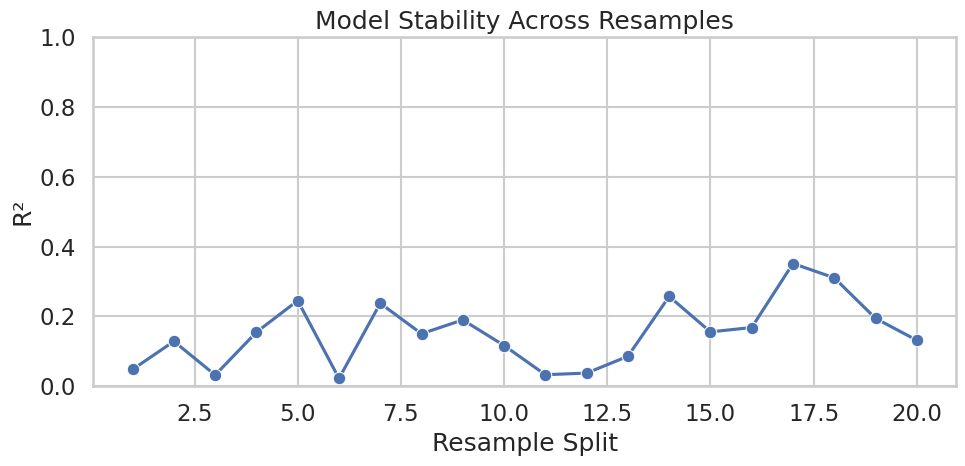

In [5]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=stability,
    x="split",
    y="r2",
    marker="o"
)

plt.ylim(0, 1)
plt.xlabel("Resample Split")
plt.ylabel("R²")
plt.title("Model Stability Across Resamples")
plt.tight_layout()
plt.savefig("figures/05_model_stability.png", dpi=300)
plt.show()

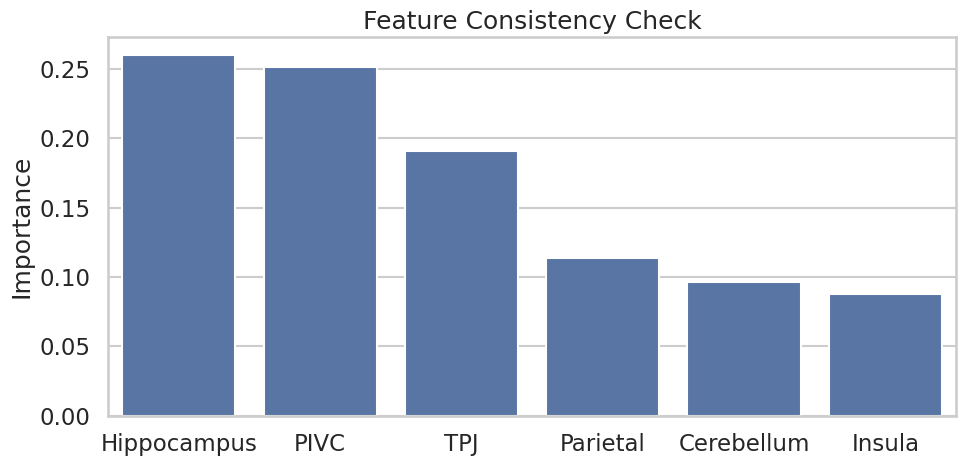

In [6]:
model.fit(X, y)

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x="feature",
    y="importance"
)

plt.xlabel("")
plt.ylabel("Importance")
plt.title("Feature Consistency Check")
plt.tight_layout()
plt.savefig("figures/05_feature_consistency.png", dpi=300)
plt.show()

In [7]:
stability.to_csv("outputs/05_model_stability.csv", index=False)
importance.to_csv("outputs/05_feature_consistency.csv", index=False)

stability["r2"].describe()

,r2
count,20.000000
mean,0.152324
std,0.095064
min,0.021935
25%,0.076031
50%,0.152352
75%,0.205014
max,0.351446
